# Fase 4 · Diseño experimental y línea base

**Universidad:** UNIFRANZ — **Materia:** Minería de Datos.

**Integrantes:** Milenka Melody Chuquimia Osco; Edson Teddy Tito Chuquimia; Carlos Daniel Valverde Mendoza; Alvaro Luis Carlos del Carpio Blanco; Marcelo Josue Escobar Chipana.

Clasificación retrospectiva de registros completos. La población corresponde a los estudiantes universitarios representados en el CSV. La etiqueta no es un diagnóstico clínico. No se demuestra causalidad, representatividad institucional ni detección anticipada. El KPI descriptivo es 24,974 % de etiquetas High; no mide calidad predictiva.


## Problema, objetivo y protocolo previo

Predecir `Burnout_Risk_Level` (Low, Medium, High), con especial atención a High. Es clasificación multiclase: el objetivo es categórico y los códigos no representan distancias. Los 14 predictores y las particiones congeladas se heredan de Fase 3. No se vuelven a dividir, limpiar ni transformar previamente. El protocolo se guarda antes de obtener resultados.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "wrangler/03_PREPARACION_DATOS/artefactos/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "wrangler/04_MODELADO"))
from eduanalytics_modelado import core
from eduanalytics_modelado.academico import texto, metricas, matrices, presentar_modelo, presentar_comparacion
import pandas as pd
from IPython.display import display
entradas = core.verificar_entradas()
print("Python:", core.versiones()["Python"], "scikit-learn:", core.versiones()["scikit-learn"])
print("CSV:", entradas["input"]["path"], "SHA-256:", entradas["input"]["sha256"])
directory = core.preparar()
config = core.leer(directory / "protocolo.json")
print("Experimento:", directory.name)
print("Protocolo SHA-256:", core.sha(directory / "protocolo.json"))

Python: 3.10.6 scikit-learn: 1.7.2
CSV: dataset/ai_student_impact_dataset (1).csv SHA-256: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5
Experimento: 3db94eb69df3c875
Protocolo SHA-256: bd38e7552d627286cae63e7ac35aa4deb1ce8b463cc9791ae63e97517a14dd61


## Datos y particiones

Entrenamiento 35.000; validación 7.500; prueba 7.500. Los conteos de prueba siguientes proceden del manifiesto previo. Las etiquetas de prueba no se cargan aquí para evaluar candidatos. Student_ID, _row_id y objetivo quedan fuera de X. GPA final y retención se incluyen bajo el alcance retrospectivo.

In [2]:
display(pd.DataFrame([{ "partición": n, "registros": v["rows"], **v["class_counts"] } for n,v in entradas["partitions"].items()]))
X, y, trace = core.cargar("train")
print("X:", X.shape, "y:", y.shape)
display(pd.DataFrame({"predictor": X.columns, "tipo": X.dtypes.astype(str).values}))

,partición,registros,Low,Medium,High
0,train,35000,11458,14801,8741
1,validation,7500,2455,3172,1873
2,test,7500,2456,3171,1873


X: (35000, 14) y: (35000,)


,predictor,tipo
0,Major_Category,object
1,Year_of_Study,object
2,Pre_Semester_GPA,float64
3,Weekly_GenAI_Hours,float64
4,Primary_Use_Case,object
5,Prompt_Engineering_Skill,object
6,Tool_Diversity,int64
7,Paid_Subscription,bool
8,Traditional_Study_Hours,float64
9,Perceived_AI_Dependency,int64


## Pliegues, algoritmos y búsqueda

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` compartido por todas las familias y escenarios. Cada pipeline ajusta escalado/categorías dentro del pliegue; logística usa L2 multinomial, árbol reglas y bosque interacciones mediante un conjunto de árboles. La logística evalúa 10 configuraciones; árbol 16 aleatorias; bosque 12 aleatorias. Semilla 42 y mismas combinaciones en sensibilidad. Ejecución secuencial, un hilo: 380 ajustes CV, 6 reajustes de candidatos, 6 de Dummy y uno final, total 393.

In [3]:
folds = core._pliegues(directory)
f = pd.read_csv(directory / "pliegues.csv", sep=";")
display(pd.crosstab(f.fold, f.label).reindex(columns=core.CLASES))
display(f.head())
print("Huella pliegues:", core.sha(directory / "pliegues.csv"))
display(config["spaces"])
display(config["configurations"])

label,Low,Medium,High
fold,,,
0,2291,2961,1748
1,2292,2960,1748
2,2292,2960,1748
3,2292,2960,1748
4,2291,2960,1749


,train_position,_row_id,Student_ID,fold,label
0,0,19040,119041,1,Medium
1,1,15373,115374,1,Low
2,2,35551,135552,0,Medium
3,3,891,100892,1,Medium
4,4,15906,115907,4,Medium


Huella pliegues: 828e8dc686882e8d6e2c09ed1348aa78382c046fb0a578023ca6373392b77347


{'arbol': {'clasificador__ccp_alpha': [0.0, 0.0001, 0.001],
  'clasificador__class_weight': [None, 'balanced'],
  'clasificador__max_depth': [3, 5, 8, 12, None],
  'clasificador__min_samples_leaf': [1, 10, 50, 100],
  'clasificador__min_samples_split': [2, 10, 50]},
 'logistica': {'clasificador__C': [0.01, 0.1, 1, 10, 100],
  'clasificador__class_weight': [None, 'balanced']},
 'random_forest': {'clasificador__class_weight': [None, 'balanced'],
  'clasificador__max_depth': [8, 16, None],
  'clasificador__max_features': ['sqrt', 0.5],
  'clasificador__min_samples_leaf': [1, 5, 20],
  'clasificador__n_estimators': [150, 300]}}

{'arbol': [{'clasificador__ccp_alpha': 0.0001,
   'clasificador__class_weight': 'balanced',
   'clasificador__max_depth': 12,
   'clasificador__min_samples_leaf': 50,
   'clasificador__min_samples_split': 50},
  {'clasificador__ccp_alpha': 0.0,
   'clasificador__class_weight': None,
   'clasificador__max_depth': 12,
   'clasificador__min_samples_leaf': 50,
   'clasificador__min_samples_split': 2},
  {'clasificador__ccp_alpha': 0.001,
   'clasificador__class_weight': None,
   'clasificador__max_depth': 12,
   'clasificador__min_samples_leaf': 100,
   'clasificador__min_samples_split': 2},
  {'clasificador__ccp_alpha': 0.001,
   'clasificador__class_weight': 'balanced',
   'clasificador__max_depth': 3,
   'clasificador__min_samples_leaf': 1,
   'clasificador__min_samples_split': 50},
  {'clasificador__ccp_alpha': 0.0,
   'clasificador__class_weight': None,
   'clasificador__max_depth': None,
   'clasificador__min_samples_leaf': 50,
   'clasificador__min_samples_split': 50},
  {'clasifica

## Métricas y selección predefinida

Macro F1 es principal; Accuracy complementa. Se informa Precision/Recall/F1/Support por clase, especialmente High. Cada F1 combina precisión y recall; Macro F1 promedia las tres clases con el mismo peso, independientemente de su soporte. Accuracy es la proporción total de aciertos; puede ocultar errores de clases menos frecuentes. Los hiperparámetros se eligen por media CV de entrenamiento; esa media no es una evaluación independiente y la DE no es un intervalo de confianza. La selección entre tres candidatos del escenario principal usa mayor Macro F1 de validación; empates hasta 1e-12 se resuelven con Recall de High y simplicidad (logística, árbol, bosque). Se contrastará con Dummy. La sensibilidad no cambia el escenario final. Después de congelar selección se reajusta un pipeline nuevo con entrenamiento+validación (42.500) y luego se consulta prueba. No se retoca tras prueba.

$$\mathrm{Macro\ F1}=\frac{F1_{Low}+F1_{Medium}+F1_{High}}{3}$$

$$P_{High}=\frac{TP_{High}}{TP_{High}+FP_{High}},\qquad R_{High}=\frac{TP_{High}}{TP_{High}+FN_{High}}$$

In [4]:
display(config["selection"])
display(config["versions"])
display(config["fit_budget"])

{'baseline': 'reference; report lack of improvement explicitly',
 'candidates': ['logistica', 'arbol', 'random_forest'],
 'metric': 'validation_macro_f1',
 'scenario': 'principal',
 'tie_atol': 1e-12,
 'tie_breakers': ['recall_High',
  'logistica < arbol < random_forest',
  'structural_cost']}

{'Python': '3.10.6',
 'ipykernel': '7.3.0',
 'joblib': '1.6.0',
 'matplotlib': '3.10.9',
 'nbclient': '0.11.0',
 'nbformat': '5.11.1',
 'numpy': '2.2.6',
 'pandas': '2.3.3',
 'scikit-learn': '1.7.2',
 'scipy': '1.15.3',
 'seaborn': '0.13.2',
 'threadpoolctl': '3.7.0'}

{'candidate_refits': 6,
 'dummy_cv_and_refit': 6,
 'final_refit': 1,
 'search_cv': 380,
 'total': 393}

## Línea base real

`DummyClassifier(strategy="most_frequent")` aprende la clase mayoritaria de entrenamiento. Se ajusta con los mismos cinco pliegues y se evalúa en entrenamiento y validación. Sirve para comprobar cuánto aportan los predictores.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,fold,fit_time,score_time,test_score,train_score
0,0,0.013095,0.030099,0.198173,0.198126
1,1,0.009856,0.011274,0.198126,0.198138
2,2,0.010248,0.011636,0.198126,0.198138
3,3,0.010200,0.010780,0.198126,0.198138
4,4,0.008155,0.008800,0.198126,0.198138


...

,partición,Macro F1,Accuracy
0,train,0.198135,0.422886
1,validation,0.198151,0.422933


,f1,precision,precision_undefined,recall,support
Low,0.0,0.0,True,0.0,2455
Medium,0.594453,0.422933,False,1.0,3172
High,0.0,0.0,True,0.0,1873


Macro F1 = **0.198151**, Accuracy = **0.422933**. High: Precision **0.000000** y Recall **0.000000**. El soporte representa registros de cada etiqueta.

Las clases marcadas con `precision_undefined=True` no reciben predicciones. Su precisión es indefinida; el cálculo usa cero mediante `zero_division=0`.

Brecha Macro F1 entrenamiento−validación = **-0.000016**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

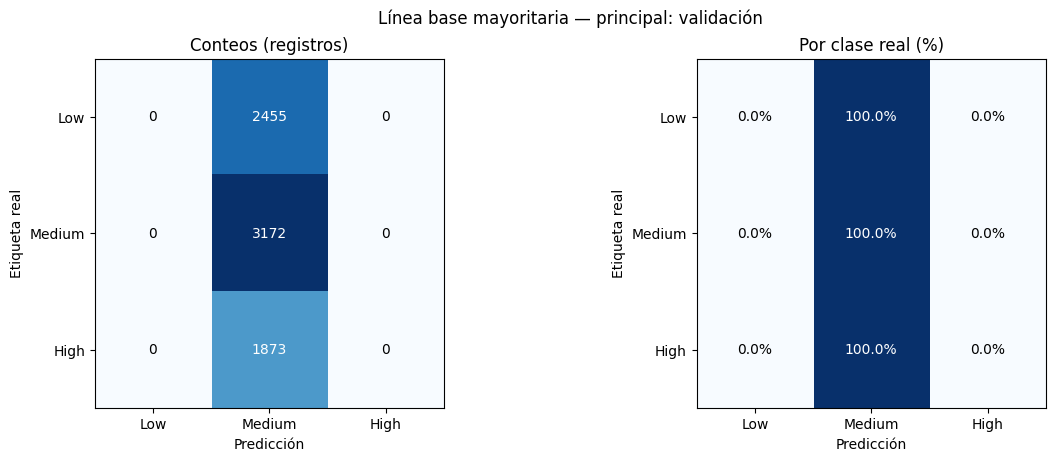

High→Low: **0**; High→Medium: **1873**. Low→High: **0**; Medium→High: **0**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,6,predict and predict_proba; full pipeline,0.394543,None,2026-10-09T19:41:20.135378+00:00,0.000498,0.000639


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

La clase mayoritaria aprendida es **Medium**. Predecirla siempre sirve como referencia mínima: Accuracy puede parecer apreciable mientras Low y High tienen Recall cero. El KPI 24,974 % describe etiquetas y no este desempeño.

### Conclusión del experimento
Macro F1 de validación **0.198151**; Recall de High **0.000000**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

{'best_params': {},
 'cv': {'configurations': 1,
  'fits': 6,
  'fold_scores': [0.19817287420941673,
   0.19812583668005354,
   0.19812583668005354,
   0.19812583668005354,
   0.19812583668005354],
  'macro_f1_mean': 0.19813524418592618,
  'macro_f1_std': 1.8815011745276777e-05},
 'estimator_classes': ['High', 'Low', 'Medium'],
 'experiment_id': '3db94eb69df3c875',
 'interpretation': {'majority_class': 'Medium'},
 'model': 'dummy',
 'overfit_gap': -1.567959619713788e-05,
 'predictors': ['Major_Category',
  'Year_of_Study',
  'Pre_Semester_GPA',
  'Weekly_GenAI_Hours',
  'Primary_Use_Case',
  'Prompt_Engineering_Skill',
  'Tool_Diversity',
  'Paid_Subscription',
  'Traditional_Study_Hours',
  'Perceived_AI_Dependency',
  'Institutional_Policy',
  'Anxiety_Level_During_Exams',
  'Post_Semester_GPA',
  'Skill_Retention_Score'],
 'scenario': 'principal',
 'train': {'accuracy': 0.4228857142857143,
  'by_class': {'High': {'f1': 0.0,
    'precision': 0.0,
    'precision_undefined': True,
    

In [5]:
baseline = core.entrenar("dummy", directory=directory)
presentar_modelo("dummy", directory=directory)

## Límites y referencias

Posible circularidad con la etiqueta de fórmula desconocida; origen sintético no confirmado. Fase 2 exploró todo el CSV: prueba es interna y reservada, no una cohorte externa nunca inspeccionada. [Validación cruzada](https://scikit-learn.org/1.7/modules/cross_validation.html) y [métricas](https://scikit-learn.org/1.7/modules/model_evaluation.html).